# Notebook 02: Classical Solver Baseline

Solve the P&C insurance bundling ILP using PuLP (CBC solver) to establish the ground truth optimal solution across all LTM scaling instances. This serves as the baseline for comparing DQI and QAOA quantum approaches.

**Data source**: LTM formal specification (20 coverages, 9 families, 10 packages). CSVs live in `Travelers/docs/data/YQH26_data/`; notebooks load them via `Path("../../docs/data/YQH26_data")`.

**Scaling instances**: n = 10, 21, 20, 50, 200 binary decision variables.

In [3]:
import sys, time, json
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.insurance_model import (
    InsuranceCoverage, BundlingProblem, CompatibilityRule, DependencyRule,
    build_ilp, solve_ilp, get_ilp_matrices, load_ltm_instance, subsample_problem,
)

ModuleNotFoundError: No module named 'pandas'

## 1. Load LTM Instance Data

The LTM formal specification provides 20 insurance coverages across 9 families, 10 segment-based packages with per-package discounts, segment affinity matrix, dependency rules, and incompatibility constraints.

In [2]:
# Load full LTM instance (20 coverages x 10 packages = 200 binary variables)
ltm_full = load_ltm_instance(Path("../../docs/data/YQH26_data"))

print(f"Coverages: {ltm_full.N}")
print(f"Packages:  {ltm_full.M}")
print(f"Binary variables: {ltm_full.N * ltm_full.M}")
print(f"Families: {list(ltm_full.families.keys())}")
print(f"Mandatory families: {list(ltm_full.mandatory_families.keys())}")
print(f"Dependency rules: {len(ltm_full.dependency_rules)}")
print(f"Incompatibility rules: {len(ltm_full.compatibility_rules)}")
print(f"Price sensitivity beta: {ltm_full.price_sensitivity_beta}")

# Show coverage summary
cov_df = pd.DataFrame([
    {"name": c.name, "family": c.family, "price": c.price,
     "take_rate": c.take_rate, "margin_pct": c.contribution_margin_pct,
     "mandatory": c.is_mandatory_in_family}
    for c in ltm_full.coverages
])
cov_df

Coverages: 20
Packages:  10
Binary variables: 200
Families: ['auto_base', 'property_base', 'auto_physical', 'auto_medical', 'motorist_protect', 'auto_ancillary', 'property_addon', 'liability_extend', 'specialty_peril']
Mandatory families: ['auto_base', 'property_base']
Dependency rules: 6
Incompatibility rules: 3
Price sensitivity beta: 1.2


,name,family,price,take_rate,margin_pct,mandatory
0,auto_liability_basic,auto_base,720.0,0.88,0.22,True
1,auto_liability_enhanced,auto_base,1180.0,0.45,0.28,True
2,homeowners,property_base,1450.0,0.65,0.25,True
3,condo_owners,property_base,580.0,0.35,0.27,True
4,renters,property_base,220.0,0.30,0.32,True
5,collision,auto_physical,480.0,0.62,0.24,False
6,comprehensive,auto_physical,320.0,0.58,0.26,False
7,medical_payments,auto_medical,95.0,0.38,0.35,False
8,personal_injury_protection,auto_medical,210.0,0.42,0.20,False
9,uninsured_motorist,motorist_protect,175.0,0.48,0.30,False


In [3]:
# Define scaling instances: (n_coverages, n_packages, n_vars)
# These match the hackathon challenge scaling ladder
sizes = [
    (5,  2,  10),   # Tiny: brute-force feasible
    (7,  3,  21),   # Small
    (10, 2,  20),   # Medium-small
    (10, 5,  50),   # Medium
    (20, 10, 200),  # Full LTM instance
]

# Create subsampled problems for each size
problems = {}
for n_cov, n_pkg, n_vars in sizes:
    prob = subsample_problem(ltm_full, n_coverages=n_cov, n_packages=n_pkg)
    problems[n_vars] = prob
    print(f"n={n_vars:>3d}: {prob.N} coverages x {prob.M} packages, "
          f"{len(prob.dependency_rules)} deps, {len(prob.compatibility_rules)} incompat, "
          f"families={list(prob.families.keys())}")

n= 10: 5 coverages x 2 packages, 0 deps, 0 incompat, families=['auto_base', 'property_base']
n= 21: 7 coverages x 3 packages, 0 deps, 0 incompat, families=['auto_base', 'property_base', 'auto_physical']
n= 20: 10 coverages x 2 packages, 0 deps, 0 incompat, families=['auto_base', 'property_base', 'auto_physical', 'auto_medical', 'motorist_protect']
n= 50: 10 coverages x 5 packages, 0 deps, 0 incompat, families=['auto_base', 'property_base', 'auto_physical', 'auto_medical', 'motorist_protect']
n=200: 20 coverages x 10 packages, 6 deps, 3 incompat, families=['auto_base', 'property_base', 'auto_physical', 'auto_medical', 'motorist_protect', 'auto_ancillary', 'property_addon', 'liability_extend', 'specialty_peril']


## 2. Solve All Scaling Instances with Classical Solver (PuLP CBC)

We solve each instance size to establish the classical optimal objective value and solution vector. These serve as ground truth for quantum algorithm comparison.

In [4]:
results = {}
for n_vars, prob in problems.items():
    t0 = time.perf_counter()
    result = solve_ilp(prob)
    elapsed = time.perf_counter() - t0
    result["solve_time_s"] = elapsed
    results[n_vars] = result

    print(f"=== n={n_vars} ({prob.N} cov x {prob.M} pkg) ===")
    print(f"  Status:    {result['status']}")
    print(f"  Objective: {result['objective']:.4f}")
    print(f"  Time:      {elapsed*1000:.1f} ms")
    for i, pkg in enumerate(result['packages']):
        pkg_name = prob.package_names[i] if prob.package_names else f"Package {i}"
        print(f"  {pkg_name}: {pkg}")
    print()

=== n=10 (5 cov x 2 pkg) ===
  Status:    Optimal
  Objective: 710.4906
  Time:      27.7 ms
  Young Driver Budget: ['auto_liability_basic', 'homeowners']
  Young Family Starter: ['auto_liability_basic', 'homeowners']

=== n=21 (7 cov x 3 pkg) ===
  Status:    Optimal
  Objective: 1420.5509
  Time:      6.8 ms
  Young Driver Budget: ['auto_liability_basic', 'homeowners', 'collision']
  Young Family Starter: ['auto_liability_basic', 'homeowners', 'collision']
  Suburban Homeowner: ['auto_liability_enhanced', 'homeowners', 'collision']

=== n=20 (10 cov x 2 pkg) ===
  Status:    Optimal
  Objective: 951.8266
  Time:      6.3 ms
  Young Driver Budget: ['auto_liability_basic', 'homeowners', 'collision', 'personal_injury_protection', 'uninsured_motorist']
  Young Family Starter: ['auto_liability_basic', 'homeowners', 'collision', 'personal_injury_protection', 'uninsured_motorist']

=== n=50 (10 cov x 5 pkg) ===
  Status:    Optimal
  Objective: 2639.0099
  Time:      8.0 ms
  Young Driver B

### Classical Optima Summary Table

In [5]:
# Summary table of classical optima across all scaling instances
summary_rows = []
for n_vars in sorted(results.keys()):
    r = results[n_vars]
    prob = problems[n_vars]
    summary_rows.append({
        "n_vars": n_vars,
        "coverages": prob.N,
        "packages": prob.M,
        "status": r["status"],
        "objective": round(r["objective"], 4),
        "solve_time_ms": round(r["solve_time_s"] * 1000, 1),
        "search_space": f"2^{n_vars}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.set_index("n_vars", inplace=True)
summary_df

,coverages,packages,status,objective,solve_time_ms,search_space
n_vars,,,,,,
10,5,2,Optimal,710.4906,27.7,2^10
20,10,2,Optimal,951.8266,6.3,2^20
21,7,3,Optimal,1420.5509,6.8,2^21
50,10,5,Optimal,2639.0099,8.0,2^50
200,20,10,Optimal,5673.2638,21.9,2^200


## 3. Brute-Force Enumeration (n=10 Toy Instance Only)

For the smallest instance (5 coverages, 2 packages = 10 binary variables = 1024 candidates), we enumerate all feasible solutions to confirm the classical optimum and create a landscape for quantum comparison.

We only perform brute-force for n=10. For larger instances this is computationally infeasible: n=21 has 2M candidates, n=50 has ~10^15, and the full n=200 instance has ~10^60 candidates.

In [6]:
toy_problem = problems[10]  # 5 coverages x 2 packages = 10 binary variables
c_toy, A_toy, b_toy = get_ilp_matrices(toy_problem)
n_toy = toy_problem.N * toy_problem.M

# Get constraint senses from the PuLP model
model, xvars = build_ilp(toy_problem)
senses = [c.sense for c in model.constraints.values()]

# Enumerate all 2^10 = 1024 bitstrings
landscape = []
for val in range(2**n_toy):
    x = np.array([(val >> i) & 1 for i in range(n_toy)], dtype=float)
    obj = float(c_toy @ x)

    # Check feasibility using the extracted A, b matrices
    Ax = A_toy @ x
    feasible = True
    for row_idx, sense in enumerate(senses):
        if sense == 1 and Ax[row_idx] < b_toy[row_idx] - 1e-9:    # >=
            feasible = False; break
        elif sense == 0 and abs(Ax[row_idx] - b_toy[row_idx]) > 1e-9:  # ==
            feasible = False; break
        elif sense == -1 and Ax[row_idx] > b_toy[row_idx] + 1e-9:  # <=
            feasible = False; break

    bitstring = format(val, f'0{n_toy}b')[::-1]  # LSB first to match Qiskit convention
    landscape.append({"bitstring": bitstring, "objective": obj, "feasible": feasible})

landscape_df = pd.DataFrame(landscape).sort_values("objective", ascending=False)
feasible_df = landscape_df[landscape_df["feasible"]]

print(f"Instance: n={n_toy} ({toy_problem.N} coverages x {toy_problem.M} packages)")
print(f"Total bitstrings:    {len(landscape_df)}")
print(f"Feasible solutions:  {len(feasible_df)}")
print(f"\nTop 10 feasible solutions:")
feasible_df.head(10)

Instance: n=10 (5 coverages x 2 packages)
Total bitstrings:    1024
Feasible solutions:  36

Top 10 feasible solutions:


,bitstring,objective,feasible
165,1010010100,710.490567,True
197,1010001100,691.027582,True
166,0110010100,641.314476,True
198,0110001100,621.851491,True
169,1001010100,591.106007,True
177,1000110100,574.944806,True
201,1001001100,571.643022,True
209,1000101100,555.481822,True
293,1010010010,533.745812,True
170,0101010100,521.929916,True


## 4. Objective Landscape Visualization (n=10 Instance)

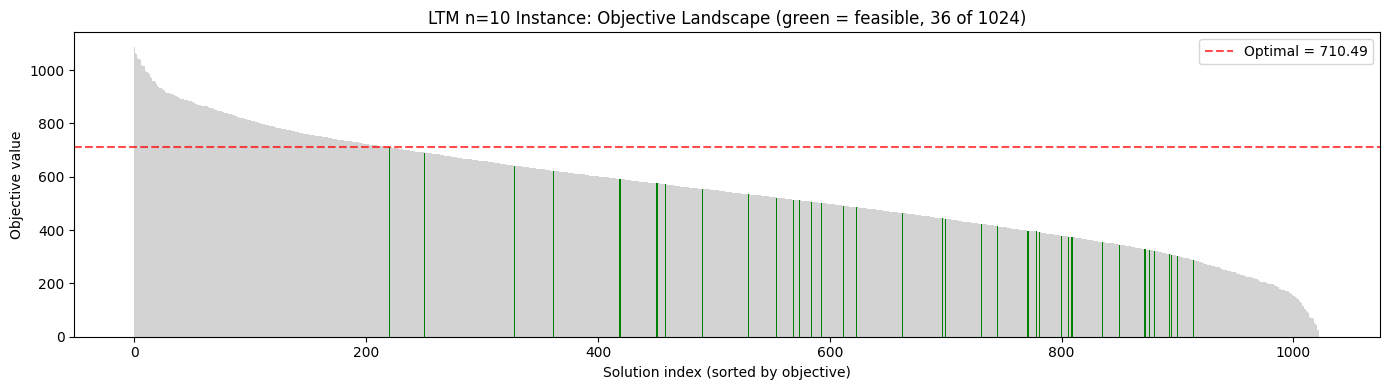

Saved to data/toy_landscape.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if f else 'lightgray' for f in landscape_df["feasible"]]
ax.bar(range(len(landscape_df)), landscape_df["objective"].values, color=colors, width=1.0)
ax.set_xlabel("Solution index (sorted by objective)")
ax.set_ylabel("Objective value")
ax.set_title(f"LTM n=10 Instance: Objective Landscape (green = feasible, {len(feasible_df)} of {len(landscape_df)})")

if len(feasible_df) > 0:
    opt_val = feasible_df.iloc[0]["objective"]
    ax.axhline(y=opt_val, color='red', linestyle='--', alpha=0.7, label=f'Optimal = {opt_val:.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig("../data/toy_landscape.png", dpi=100)
plt.show()
print(f"Saved to data/toy_landscape.png")

## 5. Save Baseline Results for Quantum Comparison

Save classical optima for all scaling instances so notebooks 03 (DQI) and 05 (comparison) can reference them.

In [8]:
# Build baseline dict with results for ALL scaling instances
baseline = {}
for n_vars in sorted(results.keys()):
    r = results[n_vars]
    prob = problems[n_vars]
    entry = {
        "n_coverages": prob.N,
        "n_packages": prob.M,
        "n_vars": n_vars,
        "status": r["status"],
        "objective": r["objective"],
        "packages": r["packages"],
        "solution_vector": r["solution_vector"].tolist(),
        "solve_time_s": r["solve_time_s"],
    }
    # Add brute-force stats for the n=10 toy instance
    if n_vars == 10:
        entry["num_feasible"] = int(len(feasible_df))
        entry["num_total"] = int(len(landscape_df))
    baseline[str(n_vars)] = entry

with open("../data/classical_baseline.json", "w") as f:
    json.dump(baseline, f, indent=2)

# Also save landscape for quantum comparison (n=10 only)
landscape_df.to_csv("../data/toy_landscape.csv", index=False)

print("Saved data/classical_baseline.json")
print("Saved data/toy_landscape.csv")
print(f"\nClassical optima across all instances:")
for n_vars in sorted(results.keys()):
    print(f"  n={n_vars:>3d}: objective = {results[n_vars]['objective']:.4f}")

Saved data/classical_baseline.json
Saved data/toy_landscape.csv

Classical optima across all instances:
  n= 10: objective = 710.4906
  n= 20: objective = 951.8266
  n= 21: objective = 1420.5509
  n= 50: objective = 2639.0099
  n=200: objective = 5673.2638
